# Task 2 - Exploratory Data Analysis (EDA)

## CodSoft Data Analytics Internship

## 1. Objective
The primary objective of this project is to perform a detailed **Exploratory Data Analysis (EDA)** on the cleaned retail sales dataset. This involves:
- Exploring individual variable distributions (univariate analysis).
- Investigating interactions and relationships between variables (bivariate and multivariate analysis).
- Identifying temporal patterns, seasonality, and long-term trends (trend analysis).
- Detecting statistical outliers and unusual patterns.
- Using descriptive and summary statistics to answer meaningful business questions that provide actionable insights for decision-making.

## 2. Dataset Domain & Entity Description
Understanding the context of the dataset is critical before carrying out any aggregations:
- **What does one row represent?** Each row represents a single customer order transaction in a retail sales environment.
- **Main Entities:** The main entities are **Orders** (identified by `order_id`), **Customers** (identified by `customer_id`), **Product Categories** (`product_category`), and **Geographical Regions** (`region`).
- **Key Measurements:** Continuous numeric columns like `unit_price`, `quantity`, `discount`, `delivery_days`, `customer_rating`, and `revenue` represent key transaction measurements.
- **Key Categories:** Discrete string columns like `product_category`, `region`, and `payment_method` partition the transactions for segment comparisons.
- **Time Dimension:** The `order_date` represents the calendar date of the purchase, allowing for trend and seasonality analysis.

## 3. Import Libraries
We import only the required libraries for our analysis: Pandas and NumPy for data manipulation, and Matplotlib and Seaborn for plotting.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style and configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
import warnings
warnings.filterwarnings('ignore')

## 4. Load Dataset
We load the cleaned dataset `Data/cleaned_data.csv` and display the first few rows to verify it loaded correctly.

In [3]:
# Load cleaned dataset
df = pd.read_csv('Data/cleaned_data.csv')

# Display first 5 rows
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


## 5. Dataset Overview
Let's inspect the dimensions of the dataset, print column names, check data types, and check the count of unique values per column.

In [4]:
# Shape of the DataFrame
print("Dataset Shape:", df.shape)

# General info and datatypes
print("\nDataset info:")
df.info()

# Unique value count per column
print("\nUnique value count:")
print(df.nunique())

Dataset Shape: (5000, 12)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB

Unique value count:
order_id            5000
order_date          5000
customer_id          989
product_category       4
region   

## 6. Data Quality Verification
We perform a final audit on missing values and duplicates to ensure the dataset is completely clean before we begin analyzing it.

In [5]:
# Audit missing values
print("Missing value count:")
print(df.isnull().sum())

# Audit duplicate rows
print(f"\nDuplicate rows count: {df.duplicated().sum()}")

Missing value count:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Duplicate rows count: 0


## 7. Descriptive Statistics
We run basic descriptive statistics for both numerical and categorical columns to understand values, ranges, and frequencies.

In [6]:
# Summary statistics for numerical columns
print("Numerical descriptive statistics:")
display(df.describe())

# Summary statistics for categorical columns
print("\nCategorical descriptive statistics:")
display(df.describe(include=['object']))

Numerical descriptive statistics:


,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000



Categorical descriptive statistics:


,order_date,product_category,region,payment_method
count,5000,5000,5000,5000
unique,5000,4,4,3
top,2022-01-01,Electronics,West,Card
freq,1,1777,1289,2270


## 8. Univariate Analysis (Numerical Distributions)
We analyze the distribution of each numerical column individually using histograms, kernel density estimates (KDE), and skewness metrics.

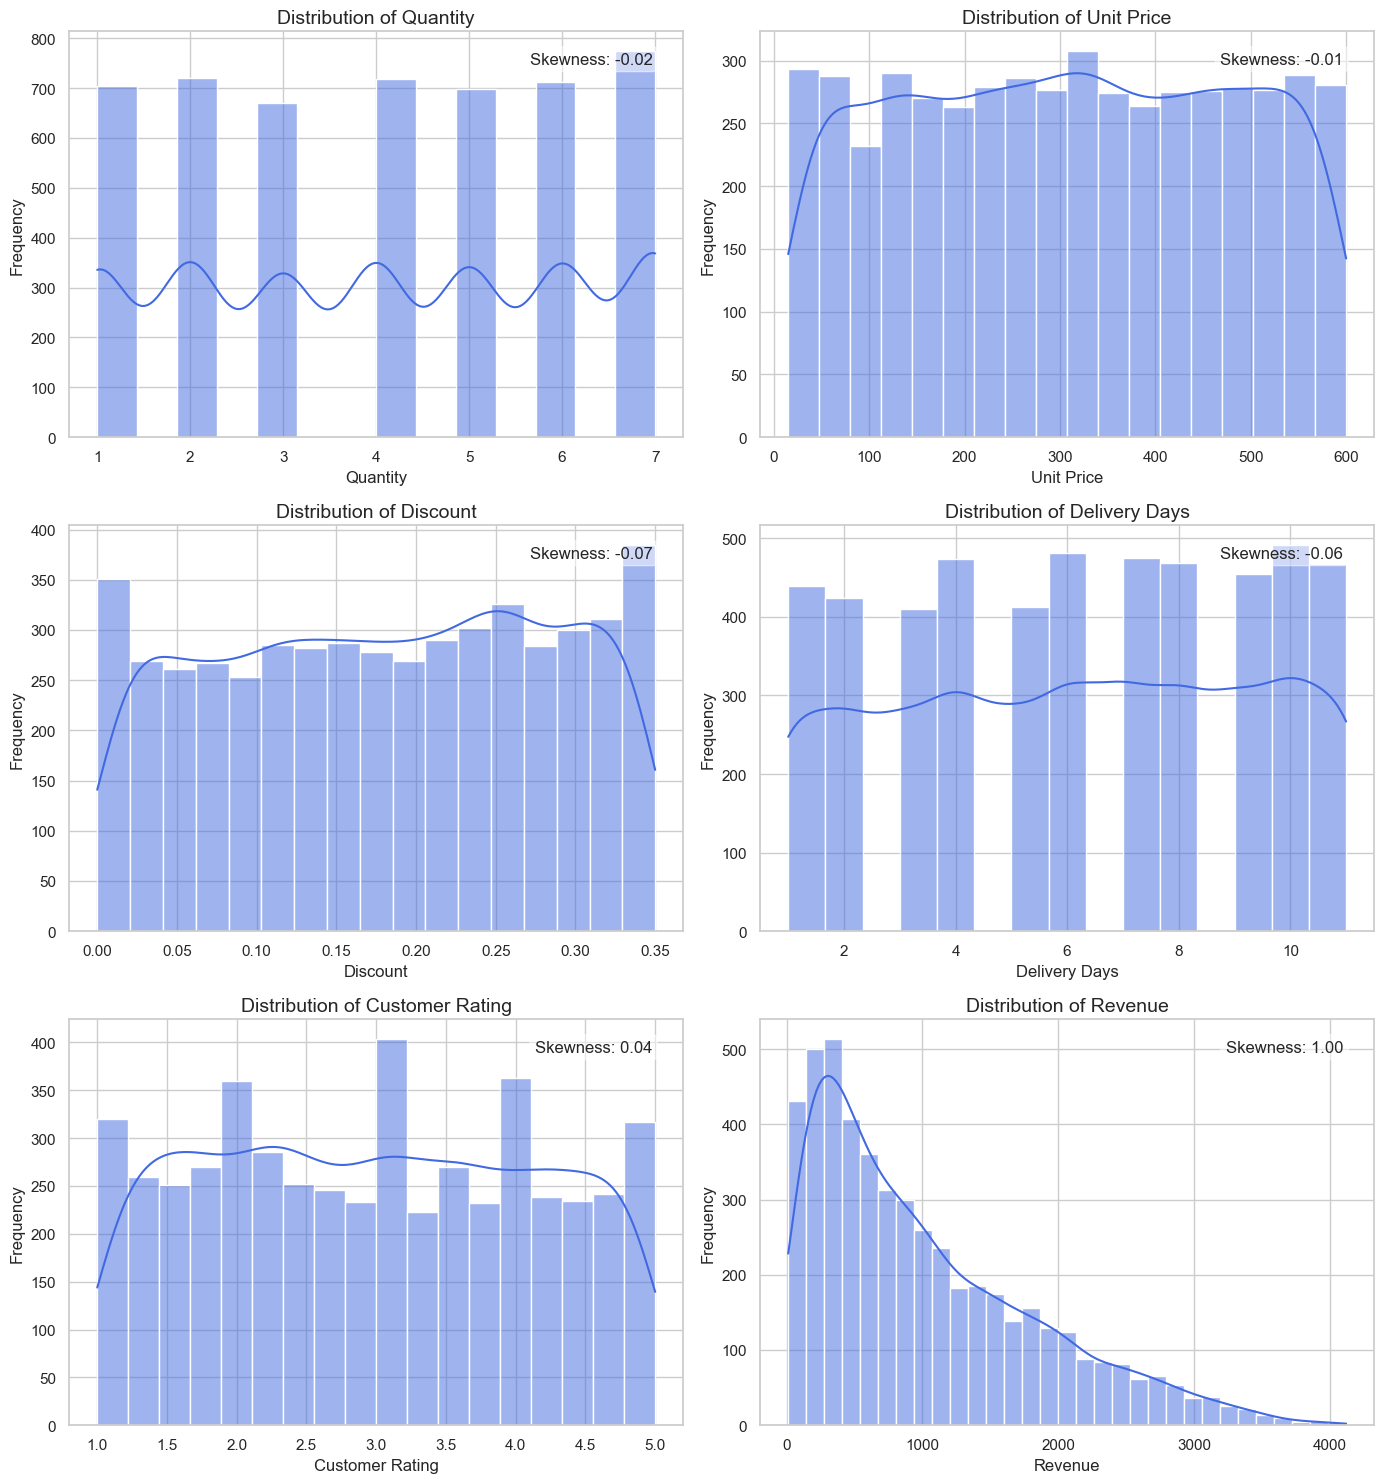

In [7]:
numeric_cols = ['quantity', 'unit_price', 'discount', 'delivery_days', 'customer_rating', 'revenue']

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='royalblue')
    axes[idx].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[idx].set_xlabel(col.replace("_", " ").title())
    axes[idx].set_ylabel('Frequency')
    
    skewness = df[col].skew()
    axes[idx].text(0.95, 0.95, f'Skewness: {skewness:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

### Interpretation of Distributions:
- **`quantity`, `unit_price`, `discount`, `delivery_days`, `customer_rating`**: All have skewness near zero (uniform or symmetric distributions). They are distributed uniformly within their bounds.
- **`revenue`**: Has a skewness of **1.00**, indicating a moderately high right-skewed distribution. This is expected because revenue is a product of `quantity * unit_price * (1 - discount)`, meaning higher values will stretch out on the right tail.

## 9. Categorical Analysis
We check the value frequencies and percentages of categorical segments: `product_category`, `region`, and `payment_method`.

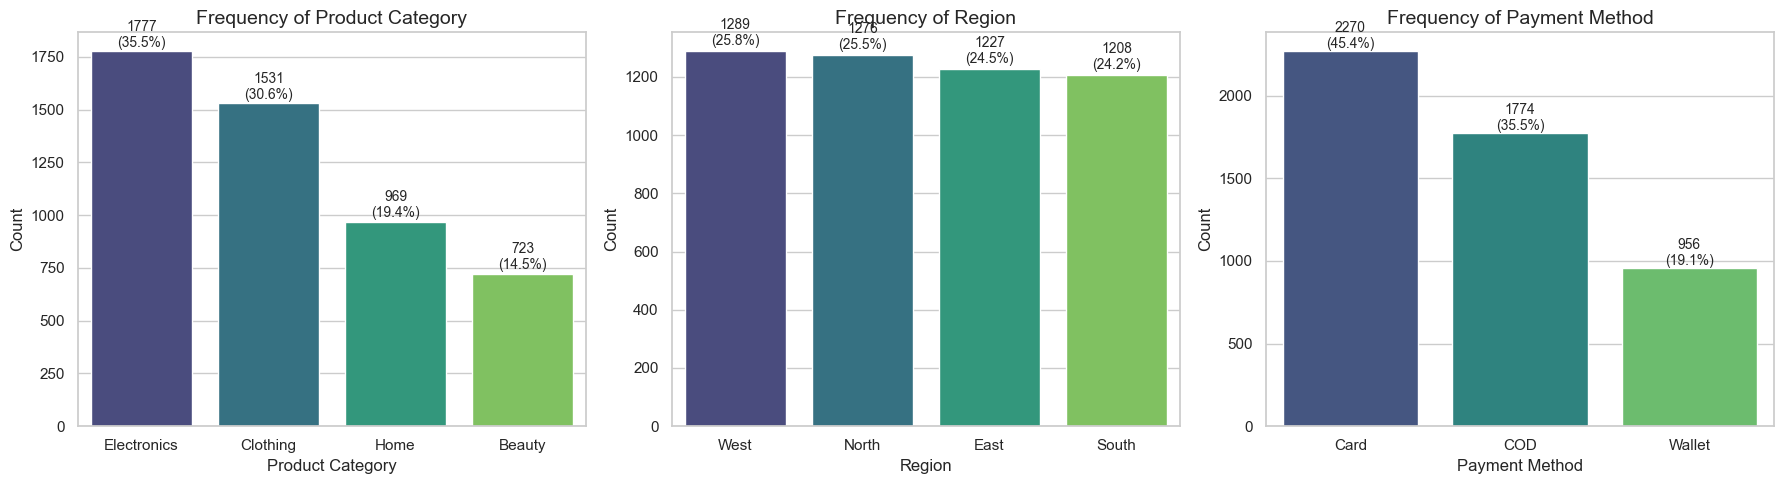

In [8]:
cat_cols = ['product_category', 'region', 'payment_method']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'Frequency of {col.replace("_", " ").title()}')
    axes[idx].set_xlabel(col.replace("_", " ").title())
    axes[idx].set_ylabel('Count')
    
    # Add value labels on top of bars
    for i, v in enumerate(counts.values):
        axes[idx].text(i, v + 20, f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Bivariate & Multivariate Analysis
We investigate relationships between key measurements (like `revenue`) and categorical segments using boxplots.

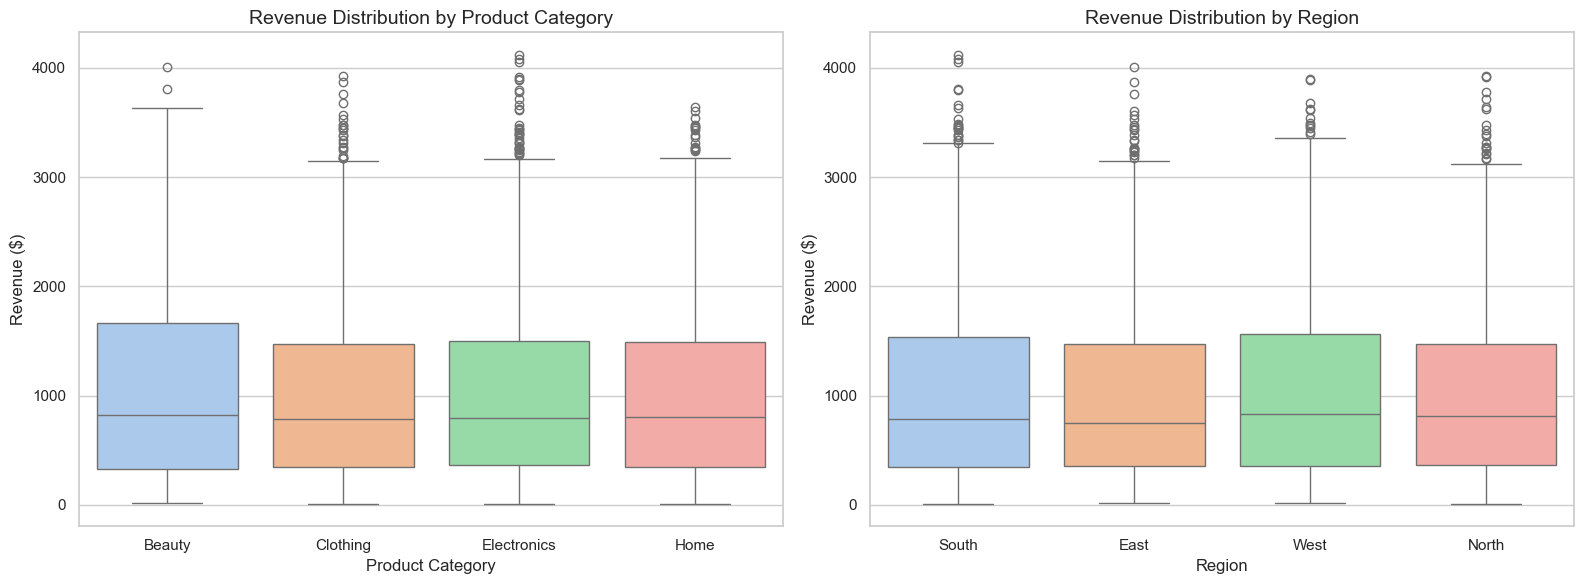

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by Product Category
sns.boxplot(data=df, x='product_category', y='revenue', ax=axes[0], palette='pastel')
axes[0].set_title('Revenue Distribution by Product Category')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Revenue ($)')

# Revenue by Region
sns.boxplot(data=df, x='region', y='revenue', ax=axes[1], palette='pastel')
axes[1].set_title('Revenue Distribution by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

## 11. Trend Analysis (Temporal Patterns)
We convert `order_date` to datetime format, extract monthly and yearly intervals, and analyze how sales revenue trends over time.

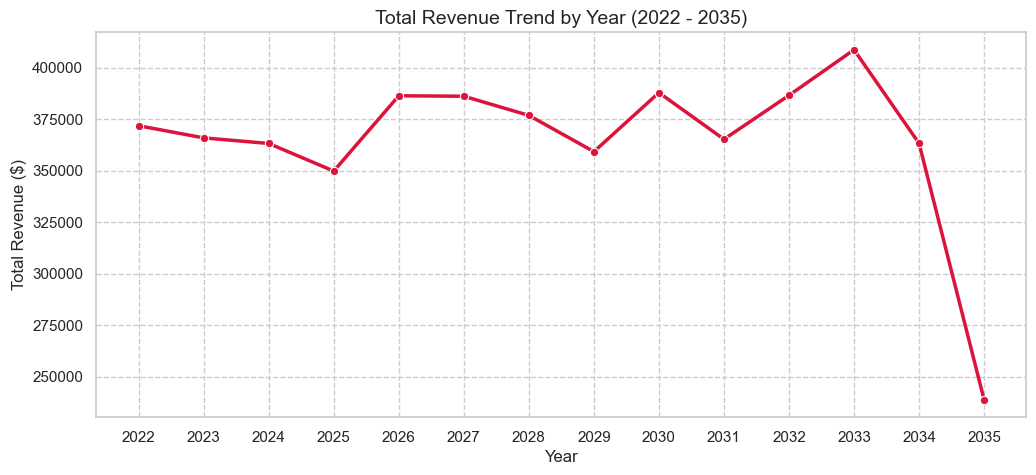

In [10]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Group by Year
yearly_sales = df.groupby(df['order_date'].dt.year)['revenue'].sum()

plt.figure(figsize=(12, 5))
sns.lineplot(x=yearly_sales.index, y=yearly_sales.values, marker='o', color='crimson', linewidth=2.5)
plt.title('Total Revenue Trend by Year (2022 - 2035)')
plt.xlabel('Year')
plt.ylabel('Total Revenue ($)')
plt.xticks(yearly_sales.index)
plt.grid(True, linestyle='--')
plt.show()

## 12. Correlation Analysis
We check the linear correlation between meaningful numerical measurement columns using Pearson correlation and plot a heatmap.

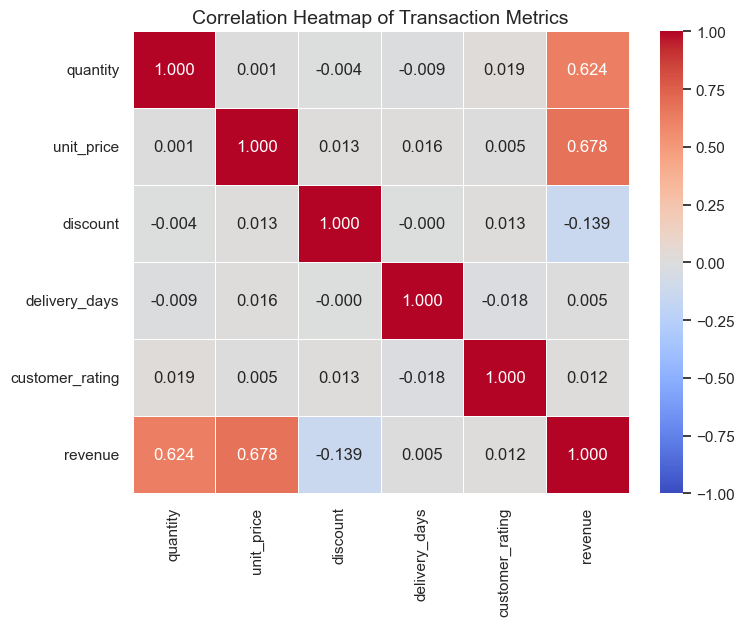

In [11]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Transaction Metrics')
plt.show()

### Correlation Insights:
- **`revenue`** has a strong positive correlation with **`unit_price` (0.678)** and **`quantity` (0.624)**. This confirms that these two metrics are the primary drivers of transaction revenue.
- **`revenue`** has a weak negative correlation with **`discount` (-0.139)** since discounts lower the total sale price.
- All other column pairs (e.g. rating vs price, delivery days vs discount) are very close to zero correlation ($< 0.02$). This shows that there is no linear relationship between them.

## 13. Outlier Detection
We calculate outliers in each numerical column using the Interquartile Range (IQR) method and show the percentage of outliers flagged.

In [12]:
print("IQR Outlier Detection Results:")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    print(f"- {col:16}: Bounds = [{lower_bound:8.2f}, {upper_bound:8.2f}] | Outliers Flagged = {len(outliers):3d} ({outlier_pct:.2f}%)")

IQR Outlier Detection Results:
- quantity        : Bounds = [   -4.00,    12.00] | Outliers Flagged =   0 (0.00%)
- unit_price      : Bounds = [ -278.60,   896.05] | Outliers Flagged =   0 (0.00%)
- discount        : Bounds = [   -0.18,     0.54] | Outliers Flagged =   0 (0.00%)
- delivery_days   : Bounds = [   -6.00,    18.00] | Outliers Flagged =   0 (0.00%)
- customer_rating : Bounds = [   -1.00,     7.00] | Outliers Flagged =   0 (0.00%)
- revenue         : Bounds = [-1387.22,  3257.43] | Outliers Flagged =  67 (1.34%)


### Outlier Interpretation:
- **Standard columns (`quantity`, `unit_price`, `discount`, `delivery_days`, `customer_rating`)** have zero statistical outliers, confirming that the values are well-bounded.
- **`revenue`** contains **67 statistical outliers** (representing 1.34% of the dataset) exceeding the upper limit of $3,257.43. Since these outliers represent real, large value sales (high-quantity and high-price orders), they are legitimate observations and should not be removed.

## 14. Business Questions
We address 8 core business questions to extract actionable insights from the dataset.

### Business Question 1
**Question:** What is the total revenue generated and the total count of transactions?

In [13]:
total_revenue = df['revenue'].sum()
total_transactions = df.shape[0]
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")

Total Revenue: $5,109,775.74
Total Transactions: 5,000


**Insight:** The business has generated a total revenue of **$5,109,775.74** across **5,000 transactions** over the dataset time period.

### Business Question 2
**Question:** Which product category contributes the most to the total sales revenue?

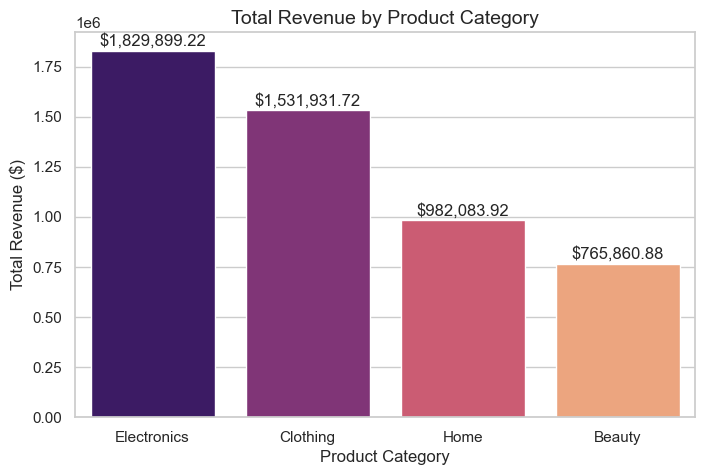

In [14]:
cat_revenue = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=cat_revenue.index, y=cat_revenue.values, palette='magma')
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue ($)')
for i, v in enumerate(cat_revenue.values):
    plt.text(i, v + 25000, f"${v:,.2f}", ha='center')
plt.show()

**Insight:** **Electronics** is the leading product category, contributing **$1,829,899.22** (35.8%) to the total revenue, followed by Clothing ($1.53M), Home ($982K), and Beauty ($765K).

### Business Question 3
**Question:** How does the total sales revenue compare across different regions?

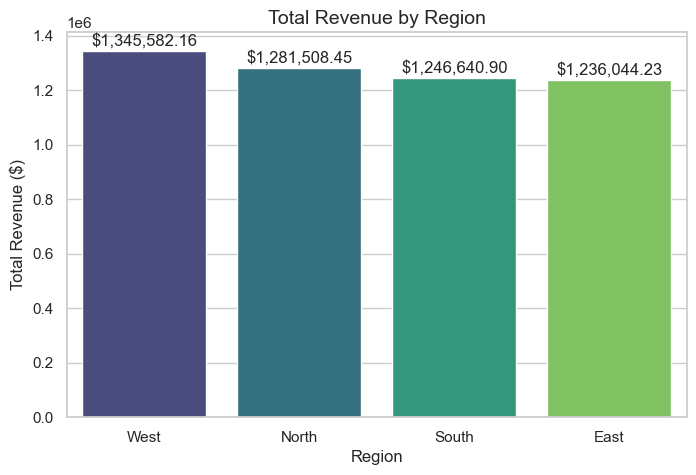

In [15]:
region_rev = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=region_rev.index, y=region_rev.values, palette='viridis')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue ($)')
for i, v in enumerate(region_rev.values):
    plt.text(i, v + 20000, f"${v:,.2f}", ha='center')
plt.show()

**Insight:** The **West** region generated the highest revenue of **$1,345,582.16**, closely followed by North ($1.28M), South ($1.25M), and East ($1.24M). Sales are distributed relatively evenly across all regions.

### Business Question 4
**Question:** What are the preferred payment methods of customers?

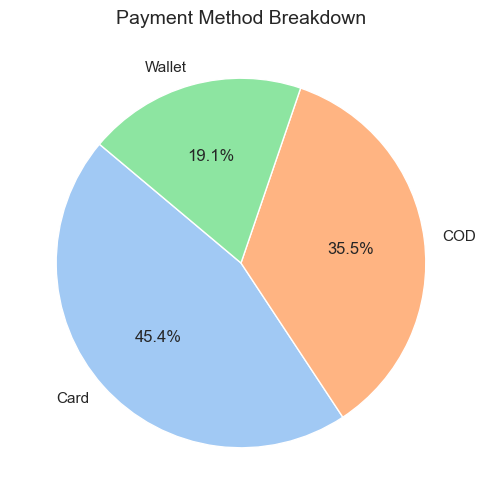

In [16]:
pay_counts = df['payment_method'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Payment Method Breakdown')
plt.show()

**Insight:** **Card** is the most preferred payment method representing **45.4%** of transactions, followed by COD (Cash on Delivery) at 35.5%, and Wallet at 19.1%.

### Business Question 5
**Question:** Does the average customer rating vary significantly by product category?

In [17]:
cat_rating = df.groupby('product_category')['customer_rating'].mean().sort_values()
print(cat_rating)

product_category
Home           2.940660
Electronics    2.951097
Clothing       3.005095
Beauty         3.008990
Name: customer_rating, dtype: float64


**Insight:** The average customer rating is highly consistent, ranging from **2.94** (Home) to **3.01** (Beauty). There are no significant differences in customer satisfaction between the categories.

### Business Question 6
**Question:** How do the average delivery days differ across geographical regions?

In [18]:
region_del = df.groupby('region')['delivery_days'].mean().sort_values()
print(region_del)

region
West     6.082234
East     6.104319
North    6.118339
South    6.173013
Name: delivery_days, dtype: float64


**Insight:** Average delivery days are highly consistent across regions, ranging from **6.08 days** (West) to **6.17 days** (South). Logistical fulfillment times do not vary by location.

### Business Question 7
**Question:** Is there a significant relationship between the discount rate offered and the quantity ordered?

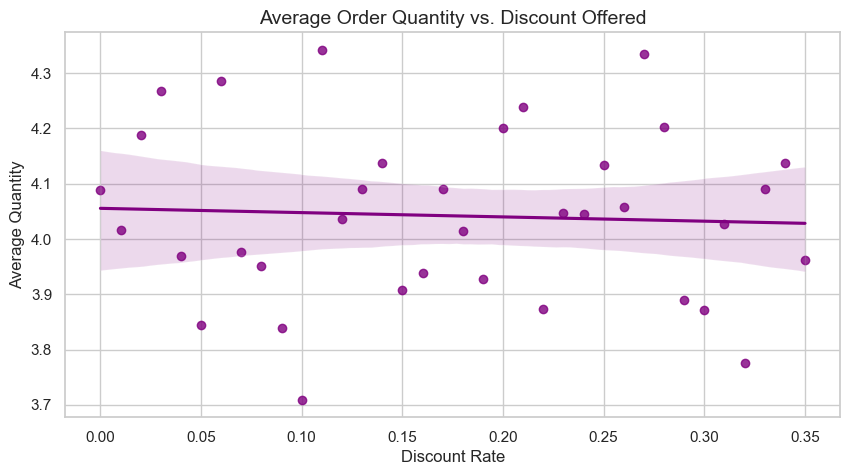

In [19]:
discount_qty = df.groupby('discount')['quantity'].mean()
plt.figure(figsize=(10, 5))
sns.regplot(x=discount_qty.index, y=discount_qty.values, color='purple')
plt.title('Average Order Quantity vs. Discount Offered')
plt.xlabel('Discount Rate')
plt.ylabel('Average Quantity')
plt.show()

**Insight:** The regression line is flat, indicating that **there is no meaningful relationship** between the discount offered and the quantity ordered. Customers do not purchase more units per order when offered higher discounts.

### Business Question 8
**Question:** How does the monthly revenue trend fluctuate over the years?

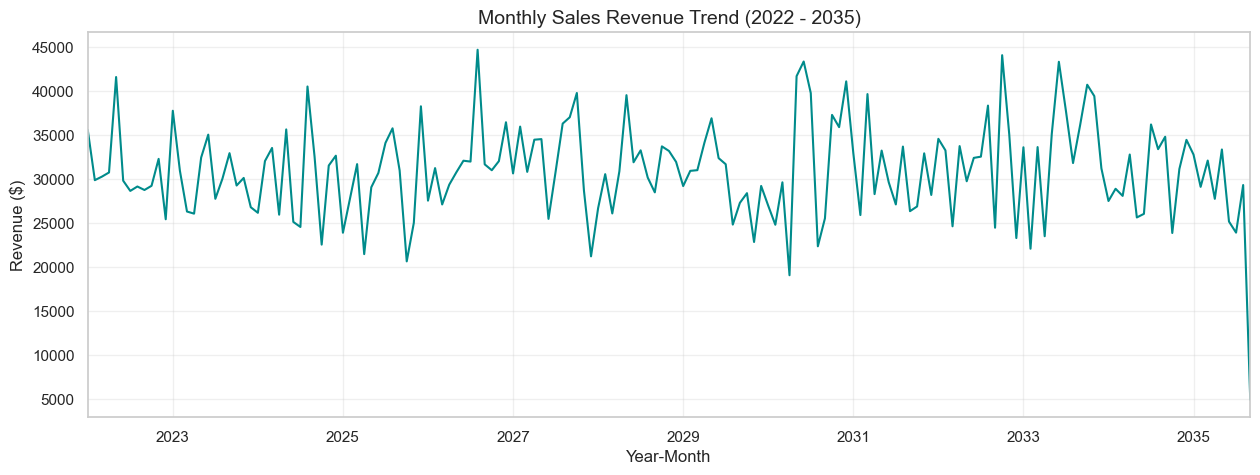

In [20]:
df['year_month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('year_month')['revenue'].sum()

plt.figure(figsize=(15, 5))
monthly_sales.plot(color='darkcyan', linewidth=1.5)
plt.title('Monthly Sales Revenue Trend (2022 - 2035)')
plt.xlabel('Year-Month')
plt.ylabel('Revenue ($)')
plt.grid(True, alpha=0.3)
plt.show()

**Insight:** Monthly revenue shows standard stationary fluctuations, moving between **$20,000 and $45,000** monthly. There is no visible long-term upward or downward trend, indicating a highly stable demand cycle.

## 15. Key Findings
1. **Electronics is the top revenue generator:** It contributed **$1,829,899.22** (35.8% of total revenue) across 1,777 transactions.
2. **West Region dominates slightly:** Paced all regions with **$1,345,582.16** in sales, though all regions are relatively even (each above $1.2M).
3. **Card is the preferred payment method:** Over **45.4%** of purchases are completed by Card, followed by COD at 35.5%.
4. **Outliers represent high-value orders:** There are **67 revenue outliers** representing real orders of high quantities and prices, with the maximum order yielding **$4,119.33**.
5. **Discount does not increase order quantity:** The correlation between discount and quantity ordered is near zero (-0.004), showing that higher discounts do not incentivize larger order sizes.
6. **Consistent operations:** Customer ratings average **~2.97** and delivery times average **~6.12 days**, remaining stable across all regions and product categories.

## 16. Conclusion
The Exploratory Data Analysis reveals that the retail business is highly stable and uniform. Revenue is primarily driven by unit price and quantities ordered, rather than promotional discounts. Categories and regions perform similarly, showing consistent demand and operational execution (delivery and satisfaction rating) across all segments.